<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 10 - Clustering

## Download the dataset

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)
!cp -r $path /content/
# !mv $path/dataset.csv ./
# !rm -r ~spotify-tracks-dataset

rm: cannot remove '~spotify-tracks-dataset': No such file or directory


## Import libraries

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np

## Q1 - Dataframe preprocessing

In [20]:
og_df = pd.read_csv('dataset.csv')
df = og_df.drop(columns=['track_id', 'Unnamed: 0', 'artists', 'album_name', 'track_name'])
info_df = og_df[['track_id', 'Unnamed: 0', 'artists', 'album_name', 'track_name']]
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = enc.fit_transform(df[["track_genre"]])
encoded_df = pd.DataFrame(encoded, columns=enc.get_feature_names_out(["track_genre"]))

df = df.drop(columns=["track_genre"]).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,...,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,cluster
0,1.782627,0.024575,False,0.629244,-0.717148,1,0.300828,0,0.551848,-0.850202,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
1,0.975633,-0.730859,False,-0.845908,-1.889980,1,-1.784744,1,-0.078993,1.831732,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,1.065299,-0.160332,False,-0.742186,-1.122669,0,-0.293288,1,-0.273826,-0.315499,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,1.692961,-0.243214,False,-1.733304,-2.312994,0,-2.039252,1,-0.457309,1.774593,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,2.186125,-0.271919,False,0.295030,-0.788711,2,-0.282750,1,-0.303145,0.463399,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,-0.548691,1.462944,False,-2.274962,-1.615656,5,-1.617326,1,-0.401507,0.977652,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9
113996,-0.503858,1.462953,False,-2.263437,-2.084789,0,-2.000082,0,-0.421369,2.042245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9
113997,-0.503858,0.404827,False,0.358416,-1.241940,0,-0.524135,0,-0.403399,1.660315,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3
113998,0.347970,0.520646,False,0.116398,-0.538241,7,-0.522942,1,-0.519731,0.198754,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4


## Q2 - Normalize features
We will use a StandardScaler on the appropriate features: popularity, duration_ms, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo

In [13]:
scale_cols = [
    'popularity','duration_ms','danceability','energy','loudness',
    'speechiness','acousticness','instrumentalness',
    'liveness','valence','tempo'
]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

## Q3 - K-Means

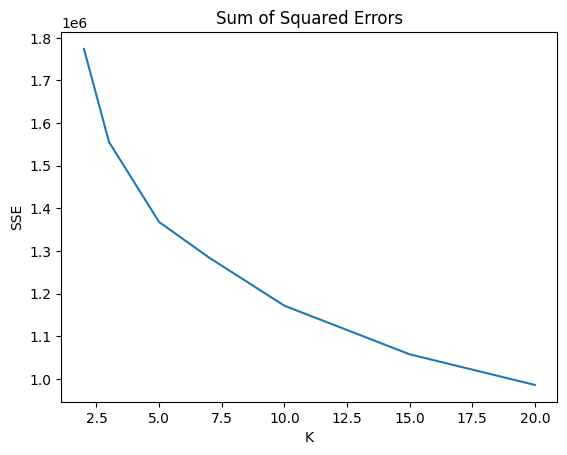

In [14]:
Ks = [2,3,5,7,10,15,20]
results = []
for k in Ks:
  kmean = KMeans(n_clusters=k, )
  kmean.fit(df)
  results.append(kmean.inertia_)

plt.plot(Ks, results)
plt.title("Sum of Squared Errors")
plt.xlabel("K")
plt.ylabel("SSE")
plt.show();

## Q4 - Select best value of `k`
Based on the plot above and the elbow method, the best value of `k` is 10.

In [15]:
k = 10 # best value per elbow method
model = KMeans(n_clusters=k)
model.fit(df)
# print(len(model.labels_))
labels = model.labels_
labels

array([7, 3, 3, ..., 3, 4, 3], dtype=int32)

## Q5 - Calculate main genre per cluster

In [16]:
df["cluster"] = labels

genre_cols = [c for c in df.columns if c.startswith("track_genre")]

dominant_pct = (
    df.groupby("cluster")[genre_cols]
    .mean()
    .max(axis=1) * 100
)

dominant_genre = (
    df.groupby("cluster")[genre_cols]
    .mean()
    .idxmax(axis=1)
    .str.replace("track_genre_", "")
)

result = pd.DataFrame({
    "genre": dominant_genre,
    "percentage": dominant_pct
})

print(result)

                 genre  percentage
cluster                           
0                sleep   11.324042
1               j-idol    1.568707
2               comedy   82.135524
3                tango    3.168720
4                happy    1.773428
5        chicago-house    1.649143
6           honky-tonk    4.159213
7          death-metal    1.456930
8             cantopop    2.657658
9                sleep   12.244898


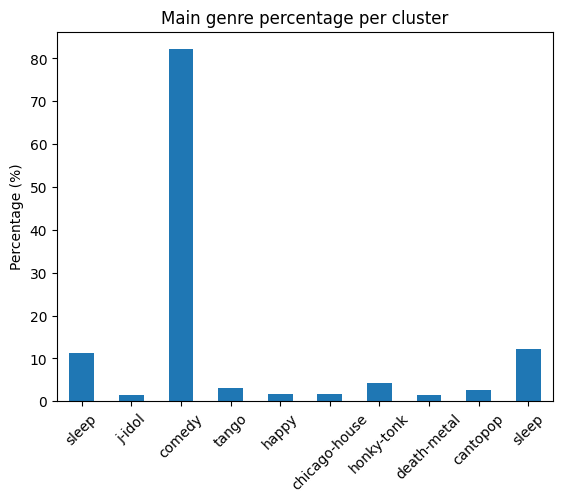

In [17]:
result.plot(
    kind="bar",
    y="percentage",
    legend=False
)
plt.xticks(range(len(result)), result["genre"], rotation=45)
plt.ylabel("Percentage (%)")
plt.title("Main genre percentage per cluster")
plt.xlabel("")
plt.show()

## Q6 - Recommend top-3 similar songs

In [34]:
top3_df = pd.concat([info_df, df], axis=1)
unclustered_df = df.drop(columns=['cluster'])
idx = 0
song = unclustered_df.iloc[idx].values.reshape(1,-1)

label = model.predict(song)

song_vec = df.iloc[idx].values

# only songs in same cluster
same = top3_df[top3_df["cluster"] == label[0]].copy()

# compute squared Euclidean distance in feature space
X = same[df.columns].values

d = np.sum((X - song_vec) ** 2, axis=1)
same["dist"] = d

# drop the original song (distance 0)
same = same[same.index != idx]

top3 = same.nsmallest(3, "dist")

# show metadata (adjust columns to what’s in info_df)
top3[["track_name", "artists", "album_name", "track_genre"]]


(22719, 135)

## Q7 - Recommend top-3 via cosine distance

## Q8 - Use `elbow` for k-group selection

## Q9 - Perform DBScan for clustering

## Q10 - Perform DBScan++ (BONUS)